# Evaluate ResNet50

In [1]:
import pandas as pd
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)      # Auto-adjust width
pd.set_option('display.max_colwidth', None)  # No truncation

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("model/resnet.csv")

y_true = df['ground_truth']
y_pred = df['prediction']
y_img = df["image"]

le = LabelEncoder()
y_true_enc = le.fit_transform(y_true)
y_pred_enc = le.transform(y_pred)

print(f"{len(le.classes_)} Classes: {le.classes_}")
print(f"Test set size: {len(y_true)}")

107 Classes: ['Albania' 'American Samoa' 'Andorra' 'Argentina' 'Australia' 'Austria'
 'Bangladesh' 'Belgium' 'Bhutan' 'Bolivia, Plurinational State of'
 'Botswana' 'Brazil' 'Bulgaria' 'Cambodia' 'Canada' 'Chile'
 'Christmas Island' 'Colombia' 'Croatia' 'Curaçao' 'Czechia' 'Denmark'
 'Dominican Republic' 'Ecuador' 'Estonia' 'Eswatini' 'Faroe Islands'
 'Finland' 'France' 'Germany' 'Ghana' 'Greece' 'Greenland' 'Guam'
 'Guatemala' 'Hong Kong' 'Hungary' 'Iceland' 'India' 'Indonesia' 'Ireland'
 'Isle of Man' 'Israel' 'Italy' 'Japan' 'Jersey' 'Jordan' 'Kazakhstan'
 'Kenya' 'Korea, Republic of' 'Kyrgyzstan'
 "Lao People's Democratic Republic" 'Latvia' 'Lebanon' 'Lesotho'
 'Liechtenstein' 'Lithuania' 'Luxembourg' 'Macao' 'Malaysia' 'Malta'
 'Mexico' 'Mongolia' 'Montenegro' 'Namibia' 'Nepal' 'Netherlands'
 'New Zealand' 'Nigeria' 'North Macedonia' 'Northern Mariana Islands'
 'Norway' 'Oman' 'Panama' 'Peru' 'Philippines' 'Poland' 'Portugal'
 'Puerto Rico' 'Qatar' 'Romania' 'Russian Federation' 'R

## Core Metrics

### Accuracy, Recall, F1-Score of whole inferenced data

- macro = average over classes (treat all classes equally)
- weighted = average weighted by class support
- micro = global TP/FP/FN over all classes

In [3]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_macro = precision_score(y_true_enc, y_pred_enc, average='macro')
recall_macro    = recall_score(y_true_enc, y_pred_enc, average='macro')
f1_macro        = f1_score(y_true_enc, y_pred_enc, average='macro')

precision_weighted = precision_score(y_true_enc, y_pred_enc, average='weighted')
recall_weighted    = recall_score(y_true_enc, y_pred_enc, average='weighted')
f1_weighted        = f1_score(y_true_enc, y_pred_enc, average='weighted')

precision_micro = precision_score(y_true_enc, y_pred_enc, average='micro')
recall_micro    = recall_score(y_true_enc, y_pred_enc, average='micro')
f1_micro        = f1_score(y_true_enc, y_pred_enc, average='micro')

print("Macro:")
print(f"Precision: {precision_macro:.4f}, Recall: {recall_macro:.4f}, F1: {f1_macro:.4f}")
print("Weighted:")
print(f"Precision: {precision_weighted:.4f}, Recall: {recall_weighted:.4f}, F1: {f1_weighted:.4f}")
print("Micro:")
print(f"Precision: {precision_micro:.4f}, Recall: {recall_micro:.4f}, F1: {f1_micro:.4f}")

Macro:
Precision: 0.7322, Recall: 0.7168, F1: 0.7166
Weighted:
Precision: 0.7292, Recall: 0.7163, F1: 0.7149
Micro:
Precision: 0.7163, Recall: 0.7163, F1: 0.7163


### Mathews Correlation Coefficient

= Classification quality across all confusion matrix elements

- Better than accuracy or F1 in multi-class geographic tasks because it detects when models perform well on majority countries but fail minorities
- Higher MCC = Captures global patterns better

In [4]:
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(y_true_enc, y_pred_enc) 
print(f"MCC: {mcc:.4f}")

MCC: 0.7137


## Per-Class Analysis

### Classification Report with Precision, Recall, F1-score per class

In [5]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, zero_division=0)

class_metrics = pd.DataFrame({
    'Country': le.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1': f1,
    'Support': support
}).round(4)

print(class_metrics.sort_values('F1', ascending=False))

                              Country  Precision  Recall      F1  Support
84              Sao Tome and Principe     0.9890  0.9677  0.9783       93
58                              Macao     0.9794  0.9500  0.9645      100
79                              Qatar     0.9691  0.9400  0.9543      100
53                            Lebanon     0.9462  0.9462  0.9462       93
1                      American Samoa     0.9406  0.9500  0.9453      100
37                            Iceland     0.9333  0.9515  0.9423      103
50                         Kyrgyzstan     0.9245  0.9608  0.9423      102
105              Virgin Islands, U.S.     0.9231  0.9600  0.9412      100
64                            Namibia     0.9314  0.9500  0.9406      100
106                     Åland Islands     0.9400  0.9400  0.9400      100
16                   Christmas Island     0.9383  0.9383  0.9383       81
70           Northern Mariana Islands     0.9783  0.9000  0.9375      100
82                             Rwanda 

Every country should have at least a F1-Score of 0.5 -> try to improve these countries

In [6]:
poor_performers = class_metrics[class_metrics['F1'] < 0.5].sort_values('F1')

print(poor_performers)

            Country  Precision  Recall      F1  Support
43            Italy     0.2083  0.1887  0.1980      106
20          Czechia     0.3438  0.2115  0.2619      104
28           France     0.3056  0.3300  0.3173      100
56        Lithuania     0.6286  0.2136  0.3188      103
88         Slovakia     0.3721  0.3168  0.3422      101
91            Spain     0.4051  0.2991  0.3441      107
18          Croatia     0.4270  0.3762  0.4000      101
36          Hungary     0.5000  0.3333  0.4000      105
77         Portugal     0.3651  0.4600  0.4071      100
76           Poland     0.3004  0.6552  0.4119      116
101  United Kingdom     0.3984  0.4667  0.4298      105
21          Denmark     0.4343  0.4257  0.4300      101
102   United States     0.5205  0.3762  0.4368      101
80          Romania     0.4000  0.4956  0.4427      113
17         Colombia     0.3841  0.5225  0.4427      111
104        Viet Nam     0.7083  0.3366  0.4564      101
39        Indonesia     0.5595  0.4123  0.4747  

### Visualization of F1-Scores per Country

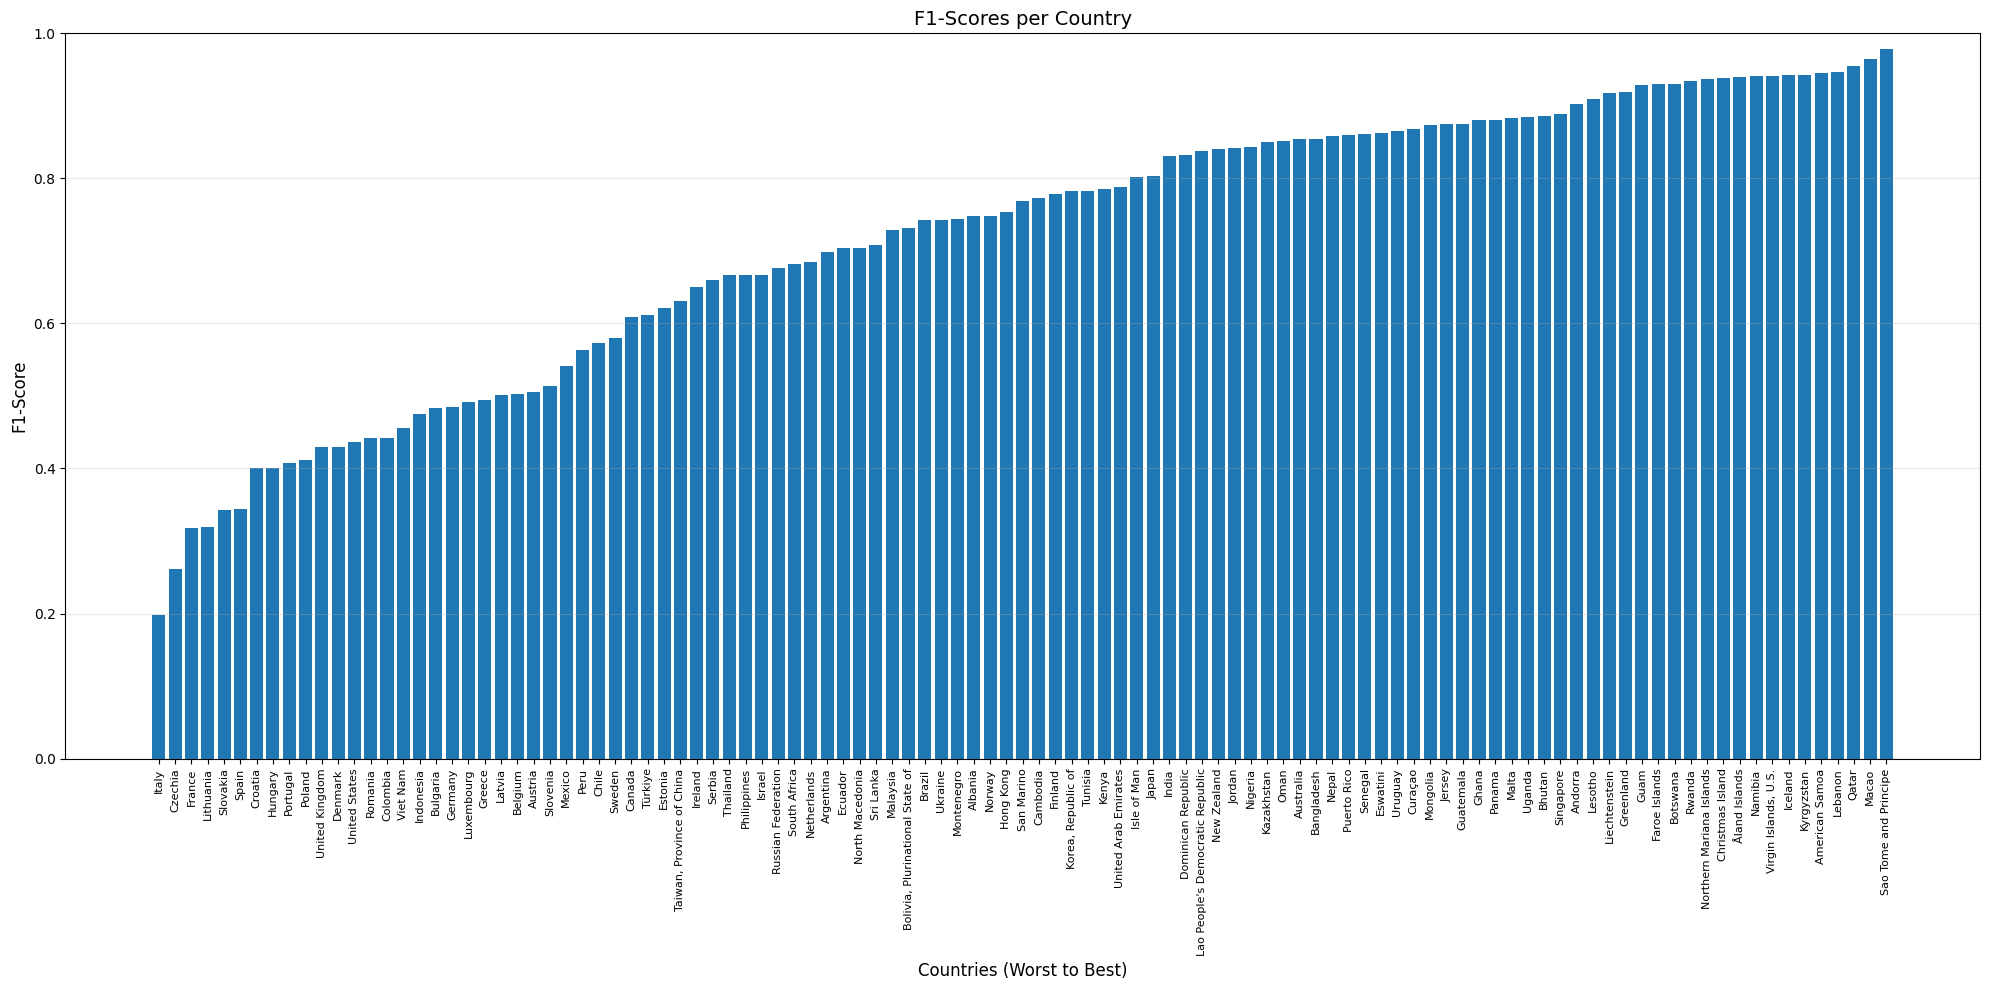

In [7]:
import matplotlib.pyplot as plt

f1_sorted = class_metrics.sort_values('F1')

plt.figure(figsize=(20, 10))
bars = plt.bar(range(len(f1_sorted)), f1_sorted['F1'])
plt.xlabel('Countries (Worst to Best)', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.title('F1-Scores per Country', fontsize=14)
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

plt.xticks(range(len(f1_sorted)), f1_sorted['Country'], rotation=90, fontsize=8, ha='center')

plt.tight_layout()
plt.show()

### Visualization of Best/Worst 5 Countries by F1

Lower fluctuation compared to ViT

One outlier:

- High Precision - Low Recall = predicts only when it's extremely confident
- Could be because probabilities are all roughly same, feature similarity with other classes (often missclassified with Latvia)

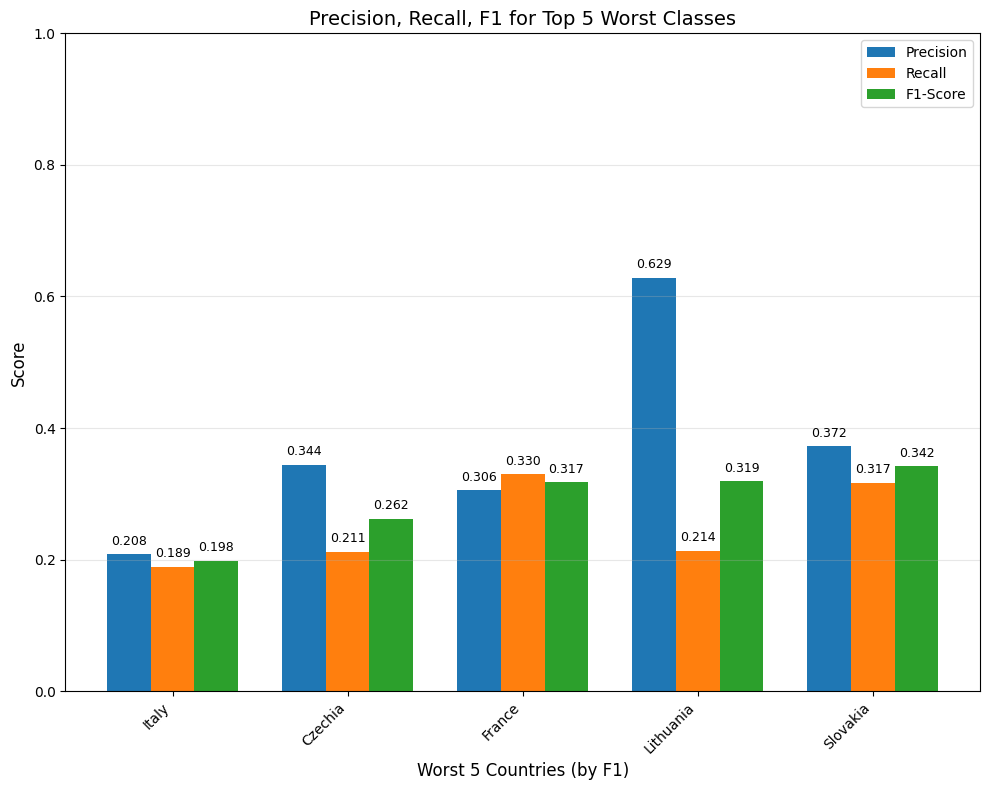

In [8]:
import matplotlib.pyplot as plt
import numpy as np

worst_5 = class_metrics.nsmallest(5, 'F1')

fig, ax = plt.subplots(figsize=(10, 8))
x = np.arange(len(worst_5))
width = 0.25

bars1 = ax.bar(x - width, worst_5['Precision'], width, label='Precision')
bars2 = ax.bar(x, worst_5['Recall'], width, label='Recall')
bars3 = ax.bar(x + width, worst_5['F1'], width, label='F1-Score',)

ax.set_xlabel('Worst 5 Countries (by F1)', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision, Recall, F1 for Top 5 Worst Classes', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(worst_5['Country'], rotation=45, ha='right', fontsize=10)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


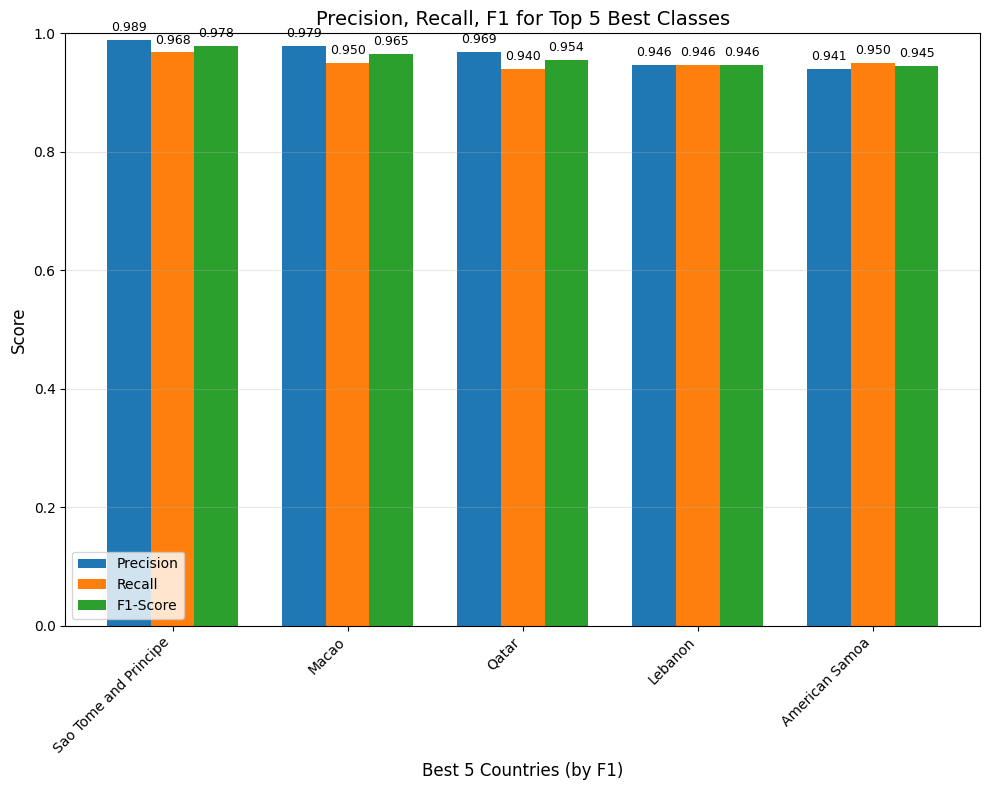

In [9]:
import matplotlib.pyplot as plt
import numpy as np

best_5 = class_metrics.nlargest(5, 'F1')

fig, ax = plt.subplots(figsize=(10, 8))
x = np.arange(len(best_5))
width = 0.25

bars1 = ax.bar(x - width, best_5['Precision'], width, label='Precision')
bars2 = ax.bar(x, best_5['Recall'], width, label='Recall')
bars3 = ax.bar(x + width, best_5['F1'], width, label='F1-Score',)

ax.set_xlabel('Best 5 Countries (by F1)', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision, Recall, F1 for Top 5 Best Classes', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(best_5['Country'], rotation=45, ha='right', fontsize=10)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


### Confusion Matrix of all countries

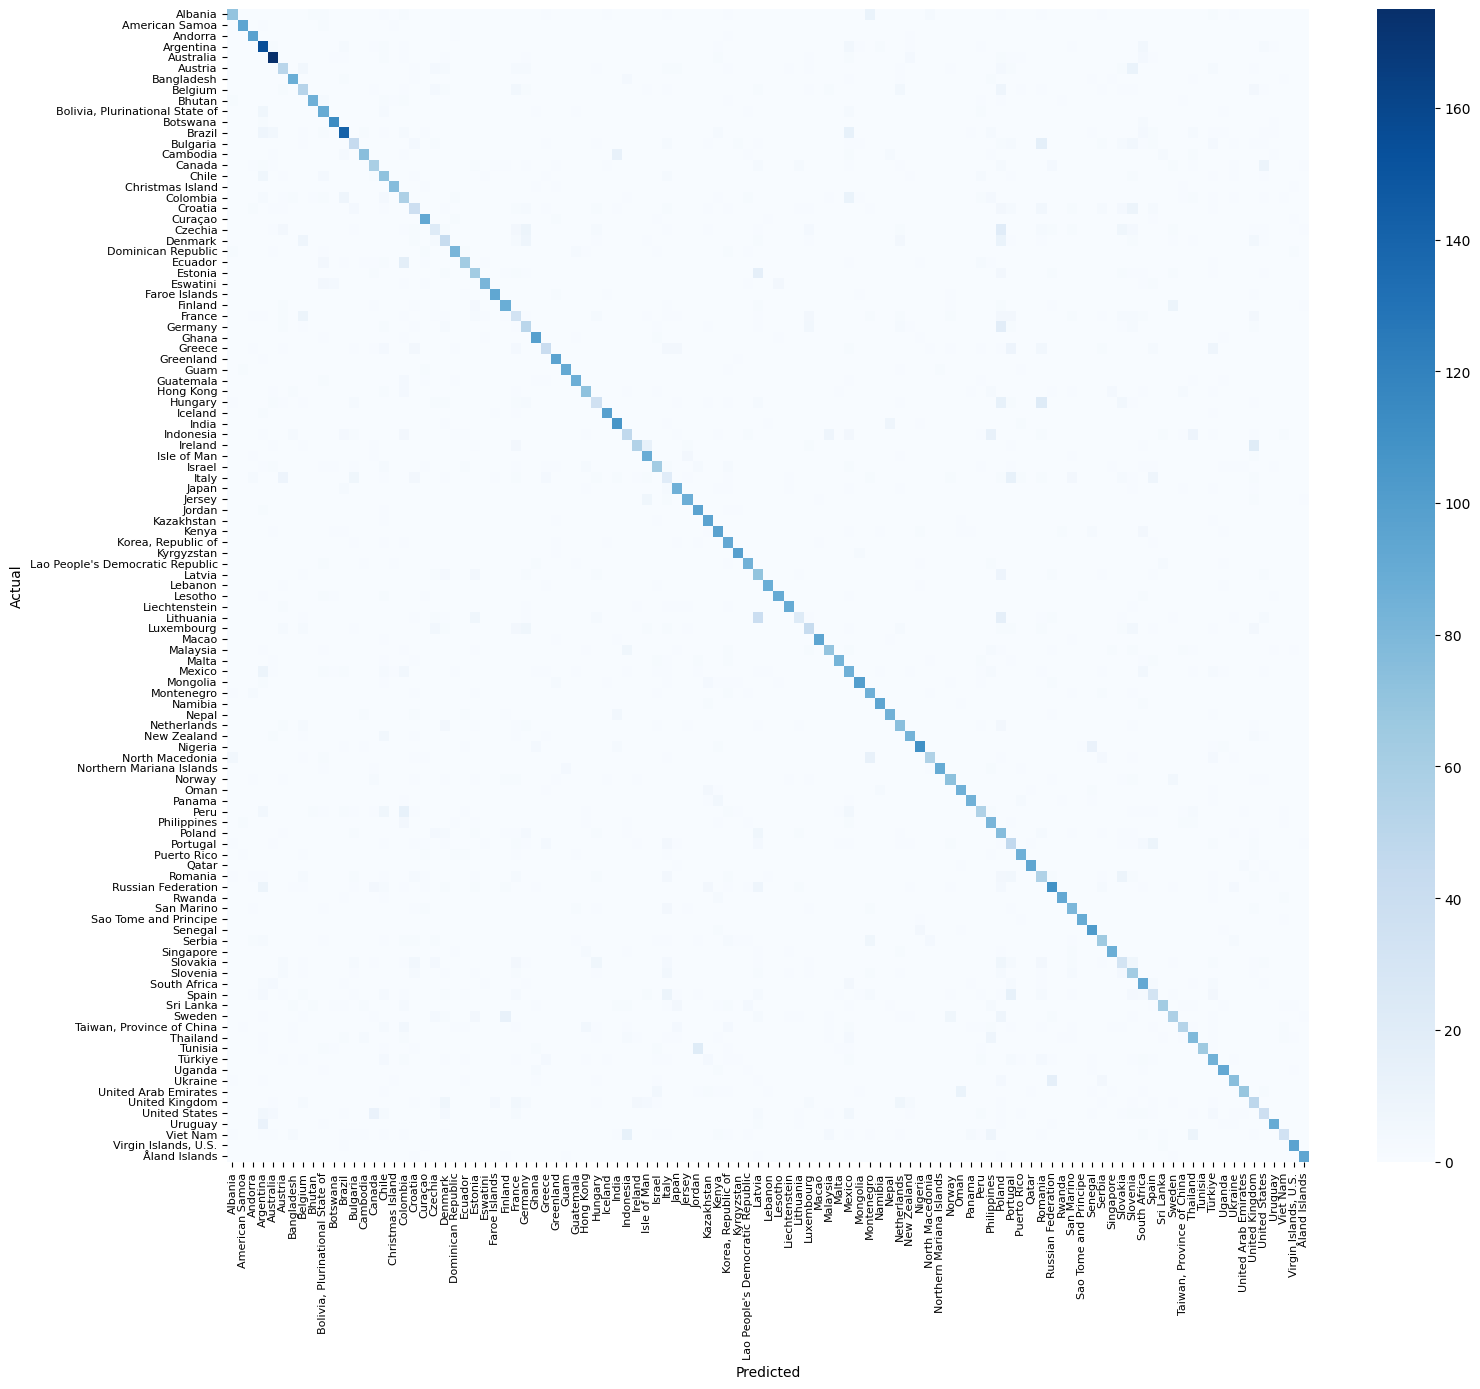

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true_enc, y_pred_enc)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### Most common Missclassification

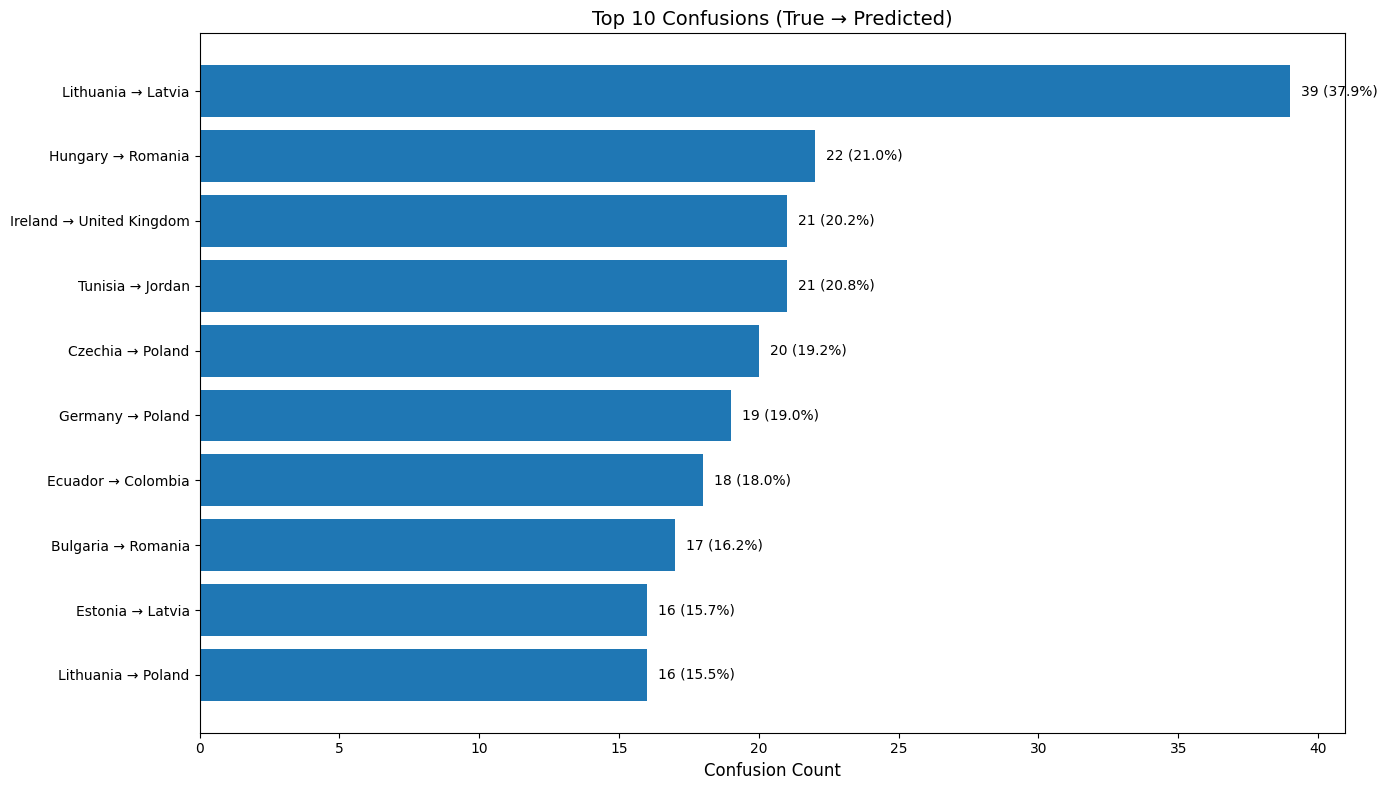

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

conf_pairs = []
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        if i != j and cm[i,j] > 0:
            conf_pairs.append({
                'True': le.classes_[i], 
                'Pred': le.classes_[j], 
                'Count': cm[i,j],
                'Error_%': cm[i,j]/cm.sum(axis=1)[i]
            })

top_confusions = pd.DataFrame(conf_pairs).nlargest(10, 'Count')

plt.figure(figsize=(14, 8))

bars = plt.barh(len(top_confusions)-1 - np.arange(len(top_confusions)), top_confusions['Count'])
plt.yticks(len(top_confusions)-1 - np.arange(len(top_confusions)), 
           [f"{row['True']} → {row['Pred']}" for _, row in top_confusions.iterrows()], 
           fontsize=10)
plt.xlabel('Confusion Count', fontsize=12)
plt.title('Top 10 Confusions (True → Predicted)', fontsize=14)

for i, bar in enumerate(bars):
    plt.text(bar.get_width() + max(top_confusions['Count'])*0.01, bar.get_y() + bar.get_height()/2, 
             f'{top_confusions["Count"].iloc[i]} ({top_confusions["Error_%"].iloc[i]:.1%})',
             va='center', fontsize=10)

plt.tight_layout()
plt.show()

## Grad-CAM Visualizations

Visualize the Grad-CAM heatmap only for the missclassified images

In [12]:
import pandas as pd
import os
import pycountry
from pathlib import Path

COUNTRY = "Italy"
country_mask = y_true == COUNTRY
country_wrong_mask = (y_true == COUNTRY) & (y_true != y_pred)

wrong_images = df[country_wrong_mask].copy()

wrong_images["path"] = wrong_images.apply(lambda row: os.path.join("data", pycountry.countries.search_fuzzy(row["ground_truth"])[0].alpha_2, row["image"]), axis=1)
wrong_images.describe()

,image,ground_truth,prediction,path
count,86,86,86,86
unique,86,1,27,86
top,0107.jpg,Italy,Portugal,data/IT/0107.jpg
freq,1,86,14,1


In [13]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
import torch
from src.model import ResNet50Model

checkpoint = torch.load('model/ResNet50Model/best.pth')
model = ResNet50Model(num_classes=len(checkpoint["label_map"]))
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)

/home/jovyan/CountryGuessr/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


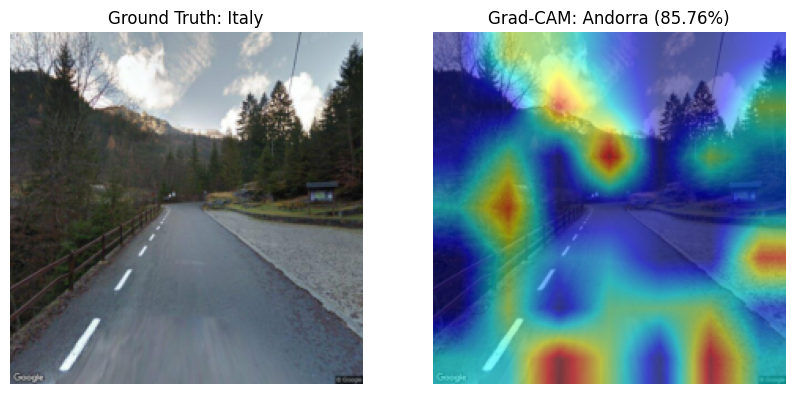

Predicted probabilities:
Andorra: 85.76%
Korea, Republic of: 5.90%
Kyrgyzstan: 1.22%
Japan: 0.91%
France: 0.91%


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import random
from PIL import Image
from torchvision import transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

label_map = checkpoint["label_map"]
idx_to_name = {v: k for k, v in label_map.items()}

from PIL import Image

def load_image_from_df(df, idx, transform):
    image_path = df.iloc[idx]["path"]
    gt_name = df.iloc[idx]["ground_truth"]

    image = Image.open(image_path).convert("RGB")
    image = transform(image)

    label = label_map[gt_name]

    return image, label, image_path

def reshape_transform(tensor, height=7, width=7):
    result = tensor.reshape(tensor.size(0), height, width, tensor.size(1))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

transform = transforms.Compose([
  transforms.Resize((224, 224)),
  transforms.ToTensor()
])

target_layers = [model.resnet50.layer4[-1].conv3]

idx = random.randint(0, len(wrong_images) - 1)
# idx = 15
top_k = 5

model.eval()

image, label, image_path = load_image_from_df(wrong_images, idx, transform)
image_tensor = image.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    outputs = model(image_tensor)
    probabilities = torch.softmax(outputs, dim=1).cpu().numpy()[0]

topk_indices = probabilities.argsort()[-top_k:][::-1]
topk_probs = probabilities[topk_indices]
topk_countries = [idx_to_name[i] for i in topk_indices]

gt_country = idx_to_name[label]

cam = GradCAM(
    model=model,
    target_layers=target_layers,
    reshape_transform=reshape_transform
)

targets = [ClassifierOutputTarget(topk_indices[0])]

grayscale_cam = cam(
    input_tensor=image_tensor,
    targets=targets,
)[0]

input_image = image.permute(1, 2, 0).cpu().numpy()
input_image = (input_image - input_image.min()) / (input_image.max() - input_image.min())

cam_image = show_cam_on_image(
    input_image,
    grayscale_cam,
    use_rgb=True
)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(input_image)
axs[0].axis("off")
axs[0].set_title(f"Ground Truth: {gt_country}")

axs[1].imshow(cam_image)
axs[1].axis("off")
axs[1].set_title(f"Grad-CAM: {topk_countries[0]} ({topk_probs[0]*100:.2f}%)")

plt.show()

print("Predicted probabilities:")
for country, prob in zip(topk_countries, topk_probs):
    print(f"{country}: {prob*100:.2f}%")